In [1]:
import pandas as pd
import numpy as np

In [2]:
from google.colab import files

uploaded = files.upload()

Saving WA_Fn-UseC_-Telco-Customer-Churn.csv to WA_Fn-UseC_-Telco-Customer-Churn.csv


In [3]:
df = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")

In [4]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [5]:
print("Dataset Shape:", df.shape)

print("\nColumn Names:")
print(df.columns.tolist())

print("\nData Types:")
print(df.dtypes)

print("\nMissing Values:")
print(df.isnull().sum())

Dataset Shape: (7043, 21)

Column Names:
['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']

Data Types:
customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object

Missing Values:
cus

In [6]:
df = df.drop("customerID", axis=1)

df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

print("Missing values after converting TotalCharges:")
print(df.isnull().sum())

print("\nUpdated data types:")
print(df.dtypes)

Missing values after converting TotalCharges:
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64

Updated data types:
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMetho

In [7]:
df = df.dropna(subset=["TotalCharges"])

df = df.reset_index(drop=True)

print("Shape after removing missing values:", df.shape)
print("\nTotal missing values:", df.isnull().sum().sum())

Shape after removing missing values: (7032, 20)

Total missing values: 0


In [8]:
y = df["Churn"].map({"No": 0, "Yes": 1})

X = df.drop("Churn", axis=1)

X = pd.get_dummies(X, drop_first=True, dtype=int)

print("Features shape:", X.shape)
print("\nTarget shape:", y.shape)

X.head()

Features shape: (7032, 30)

Target shape: (7032,)


,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,MultipleLines_Yes,...,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,1,29.85,29.85,0,1,0,0,1,0,...,0,0,0,0,0,0,1,0,1,0
1,0,34,56.95,1889.50,1,0,0,1,0,0,...,0,0,0,0,1,0,0,0,0,1
2,0,2,53.85,108.15,1,0,0,1,0,0,...,0,0,0,0,0,0,1,0,0,1
3,0,45,42.30,1840.75,1,0,0,0,1,0,...,0,0,0,0,1,0,0,0,0,0
4,0,2,70.70,151.65,0,0,0,1,0,0,...,0,0,0,0,0,0,1,0,1,0


In [9]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training features:", X_train.shape)
print("Testing features:", X_test.shape)
print("Training target:", y_train.shape)
print("Testing target:", y_test.shape)

Training features: (5625, 30)
Testing features: (1407, 30)
Training target: (5625,)
Testing target: (1407,)


In [10]:
from sklearn.linear_model import LogisticRegression

# Logistic Regression model
logistic_model = LogisticRegression(max_iter=1000, random_state=42)

# Training the model
logistic_model.fit(X_train, y_train)

# Predictions
y_pred_lr = logistic_model.predict(X_test)

print("Logistic Regression model trained successfully.")

Logistic Regression model trained successfully.


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [11]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

# Logistic Regression model
logistic_model = LogisticRegression(max_iter=2000, random_state=42)

# Train the model
logistic_model.fit(X_train_scaled, y_train)

# Make predictions
y_pred_lr = logistic_model.predict(X_test_scaled)

print("Logistic Regression model trained successfully.")

Logistic Regression model trained successfully.


In [12]:
from sklearn.tree import DecisionTreeClassifier

# Decision Tree model
decision_tree = DecisionTreeClassifier(
    random_state=42,
    max_depth=5
)

# Training model
decision_tree.fit(X_train, y_train)

# Make predictions
y_pred_dt = decision_tree.predict(X_test)

print("Decision Tree model trained successfully.")

Decision Tree model trained successfully.


In [13]:
from sklearn.ensemble import RandomForestClassifier

# Random Forest model
random_forest = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

# Train the model
random_forest.fit(X_train, y_train)

# Make predictions
y_pred_rf = random_forest.predict(X_test)

print("Random Forest model trained successfully.")

Random Forest model trained successfully.


In [14]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Calculate metrics for Logistic Regression
lr_accuracy = accuracy_score(y_test, y_pred_lr)
lr_precision = precision_score(y_test, y_pred_lr)
lr_recall = recall_score(y_test, y_pred_lr)
lr_f1 = f1_score(y_test, y_pred_lr)

# Metrics Decision Tree
dt_accuracy = accuracy_score(y_test, y_pred_dt)
dt_precision = precision_score(y_test, y_pred_dt)
dt_recall = recall_score(y_test, y_pred_dt)
dt_f1 = f1_score(y_test, y_pred_dt)

# Matricsfor Random Forest
rf_accuracy = accuracy_score(y_test, y_pred_rf)
rf_precision = precision_score(y_test, y_pred_rf)
rf_recall = recall_score(y_test, y_pred_rf)
rf_f1 = f1_score(y_test, y_pred_rf)

# Result
print("Logistic Regression:")
print("Accuracy :", round(lr_accuracy, 4))
print("Precision:", round(lr_precision, 4))
print("Recall   :", round(lr_recall, 4))
print("F1 Score :", round(lr_f1, 4))

print("\nDecision Tree:")
print("Accuracy :", round(dt_accuracy, 4))
print("Precision:", round(dt_precision, 4))
print("Recall   :", round(dt_recall, 4))
print("F1 Score :", round(dt_f1, 4))

print("\nRandom Forest:")
print("Accuracy :", round(rf_accuracy, 4))
print("Precision:", round(rf_precision, 4))
print("Recall   :", round(rf_recall, 4))
print("F1 Score :", round(rf_f1, 4))

Logistic Regression:
Accuracy : 0.8038
Precision: 0.6476
Recall   : 0.5749
F1 Score : 0.6091

Decision Tree:
Accuracy : 0.7783
Precision: 0.5807
Recall   : 0.5963
F1 Score : 0.5884

Random Forest:
Accuracy : 0.7896
Precision: 0.6258
Recall   : 0.5187
F1 Score : 0.5673


In [15]:
# Create modelcomparison table
comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest"
    ],
    "Accuracy": [
        lr_accuracy,
        dt_accuracy,
        rf_accuracy
    ],
    "Precision": [
        lr_precision,
        dt_precision,
        rf_precision
    ],
    "Recall": [
        lr_recall,
        dt_recall,
        rf_recall
    ],
    "F1 Score": [
        lr_f1,
        dt_f1,
        rf_f1
    ]
})

comparison = comparison.round(4)

# Display
comparison

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.8038,0.6476,0.5749,0.6091
1,Decision Tree,0.7783,0.5807,0.5963,0.5884
2,Random Forest,0.7896,0.6258,0.5187,0.5673


## Best Model Selection

Based on the comparison, Logistic Regression is the best-performing model for predicting customer churn. It achieved the highest accuracy 80.38%, precision 64.76%, and F1 score 60.91% among the three models. Although the Decision Tree has a slightly higher recall 59.63%, Logistic Regression provided better overall performance. Therefore, Logistic Regression was selected as the best model for this classification task.


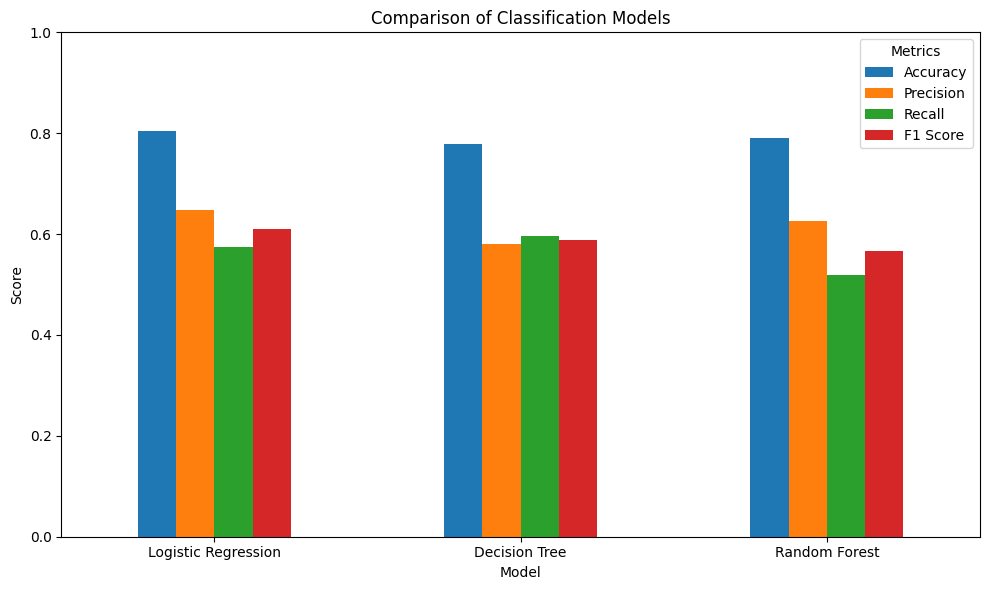

In [16]:
import matplotlib.pyplot as plt

# Model name
models = comparison["Model"]

# Plot
comparison.set_index("Model")[["Accuracy", "Precision", "Recall", "F1 Score"]].plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Comparison of Classification Models")
plt.xlabel("Model")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.legend(title="Metrics")
plt.tight_layout()
plt.show()